# Physics-Informed Neural Network (PINN) for Harmonic Motion
This notebook implements a PINN to solve the differential equations of a damped oscillator.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

## Part 1: Physical Constants & Parameters
We define the mass ($m$), spring constant ($k$), and damping coefficient ($\mu$).

In [2]:
# Part 1: Initializing Physical Constants & Parameters
m = 1.0     # Mass (kg)
k = 40.0    # Spring Constant (N/m)
mu = 0.5    # Damping Coefficient (kg/s)

## Part 2: Neural Network Architecture
We use a Fully Connected Network with Tanh activation functions for smooth derivatives.

In [3]:
# Part 2: Building Neural Network Architecture

class FCN(nn.Module):
    def __init__(self, n_input, n_output, n_hidden, n_layers):
        super().__init__()
        
        # Tanh is used because it is crucial for PINNs as it has smooth second derivatives
        activation = nn.Tanh
        self.fcs = nn.Sequential(*[
            nn.Linear(n_input, n_hidden),
            activation()
        ])
        self.fch = nn.Sequential(*[
            nn.Sequential(*[nn.Linear(n_hidden, n_hidden), activation()]) 
            for _ in range(n_layers-1)
        ])
        self.fce = nn.Linear(n_hidden, n_output)
        
    def forward(self, x):
        x = self.fcs(x)
        x = self.fch(x)
        x = self.fce(x)
        return x

# Initializing the model: 1 input (t) -> 1 output (x)
pinn = FCN(1, 1, 32, 3)

## Part 3: The Physics-Informed Loss Function
We use Automatic Differentiation to calculate the ODE residual based on Newton's Second Law:
$$m\frac{d^2x}{dt^2} + \mu\frac{dx}{dt} + kx = 0$$

In [4]:
# Part 3: The Physics-Informed Loss Function
# Loss function is the error scalar value between the actual path and AI predicted path

def physics_loss(model, t):
    t.requires_grad = True
    x = model(t)
    
    # Calculating velocity (dx/dt) using Automatic Differentiation
    dx_dt = torch.autograd.grad(x, t, torch.ones_like(x), create_graph=True)[0]
    
    # Calculating acceleration (d^2x/dt^2)
    d2x_dt2 = torch.autograd.grad(dx_dt, t, torch.ones_like(dx_dt), create_graph=True)[0]
    
    # The ODE Residual: m*a + mu*v + k*x = 0
    # The closer this is to zero, the better the AI knows Physics
    residual = m*d2x_dt2 + mu*dx_dt + k*x
    return torch.mean(residual**2)

## Part 4: Training with Position & Velocity Constraints
We train the model for 10,000 iterations to lock in the initial conditions ($x=1, v=0$).

In [5]:
# Part 4: Position + Velocity Constraints

t_physics = torch.linspace(0, 1, 40).view(-1,1).requires_grad_(True)
optimizer = torch.optim.Adam(pinn.parameters(), lr=1e-3)

print("Final Training: Locking in Position and Velocity...")

for i in range(10001): 
    optimizer.zero_grad()
    
    # 1. Physics Loss
    l_physics = physics_loss(pinn, t_physics)
    
    # 2. Data Loss (Initial Conditions)
    t0 = torch.zeros((1, 1), requires_grad=True)
    x0 = pinn(t0)
    
    # Calculate initial velocity (v0)
    v0 = torch.autograd.grad(x0, t0, torch.ones_like(x0), create_graph=True)[0]
    
    # Constraint A: Must start at x = 1
    loss_x0 = 100.0 * (x0 - 1.0)**2 
    # Constraint B: Must start with velocity v = 0 (released from rest)
    loss_v0 = 10.0 * (v0 - 0.0)**2
    
    loss = l_physics + loss_x0 + loss_v0
    loss.backward()
    optimizer.step()
    
    if i % 2000 == 0:
        print(f"Iteration {i}: Loss = {loss.item():.6f}")

print("Training Complete! The final Loss value should be very less.")

Final Training: Locking in Position and Velocity...
Iteration 0: Loss = 93.037659
Iteration 2000: Loss = 0.011713
Iteration 4000: Loss = 0.606626
Iteration 6000: Loss = 0.001258
Iteration 8000: Loss = 0.000854
Iteration 10000: Loss = 0.016954
Training Complete! The final Loss value should be very less.


## Part 5: Visualization & Comparison
Finally, we compare the AI's prediction against the analytical "Math" solution.

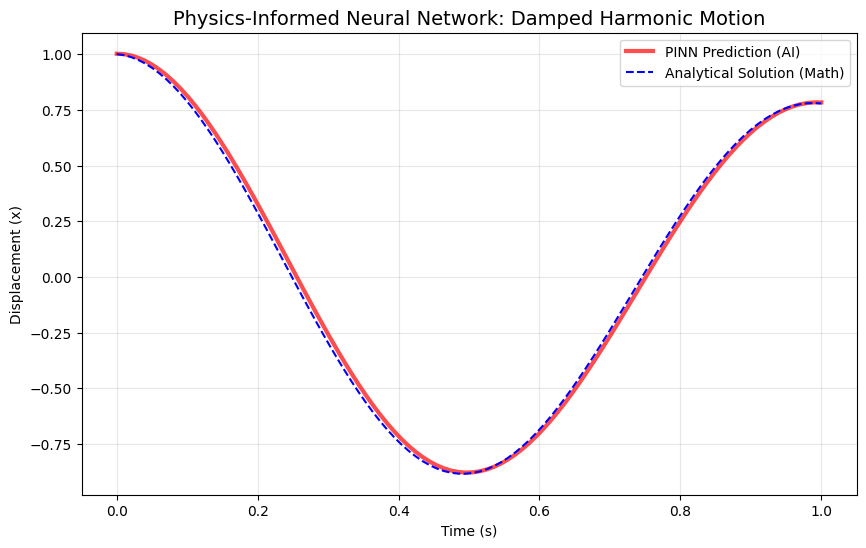

In [6]:
# BLOCK 5: Visualization & Comparison
# ==========================================
t_test = torch.linspace(0, 1, 100).view(-1,1)
x_pred = pinn(t_test).detach().numpy()

plt.figure(figsize=(10, 6))
plt.plot(t_test.numpy(), x_pred, label="PINN Prediction (AI)", color='red', linewidth=3, alpha=0.7)

# Theoretical comparison for validation
# x(t) = e^(-gamma*t) * cos(omega*t) for underdamped systems
gamma = mu / (2*m)
omega = np.sqrt(k/m - gamma**2)
x_exact = np.exp(-gamma * t_test.numpy()) * np.cos(omega * t_test.numpy())

plt.plot(t_test.numpy(), x_exact, label="Analytical Solution (Math)", color='blue', linestyle='--')
plt.title("Physics-Informed Neural Network: Damped Harmonic Motion", fontsize=14)
plt.xlabel("Time (s)")
plt.ylabel("Displacement (x)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()